# Libs

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path
import joblib
from sklearn.model_selection import ParameterGrid
from tqdm.auto import tqdm

import os
import logging
import sys
sys.path.append('../')
import src.forecasting.simulations      as sim
import src.fda.kde.estimators           as kde
import src.fda.transformations.lqdt     as lqdt

import src.fda.utils                    as fdaUtils
import src.forecasting.pipelines        as fp
import src.forecasting.accuracy         as acc
import src.forecasting.cross_validation as crossVal


In [6]:
EXECUTION_DATE : str = datetime.now().strftime('%Y%m%d')
LOG_PATH       : str = f'../logs/simulations/{EXECUTION_DATE}.log'
FILES_PATH     : str = f'../data/interim/simulation/{EXECUTION_DATE}/'
DATABASES_PATH : str = f'../data/interim/simulation/{EXECUTION_DATE}/databases/'
SIM_LQD_PATH       : str = f'../data/interim/simulation/{EXECUTION_DATE}/sim_lqds/'
KDE_LQD_PATH   : str = f'../data/interim/simulation/{EXECUTION_DATE}/kde_lqds/'
ALL_KDES_PATH  : str = f'../data/interim/simulation/{EXECUTION_DATE}/all_kdes.jbl'
CV_FILES_PATH  : str = f'../data/interim/simulation/{EXECUTION_DATE}/progress/'
CV_FC_PATH     : str = f'../data/interim/simulation/{EXECUTION_DATE}/cv/'


Path(FILES_PATH).mkdir(parents=True, exist_ok=True)
Path(DATABASES_PATH).mkdir(parents=True, exist_ok=True)
Path(CV_FILES_PATH).mkdir(parents=True, exist_ok=True)
Path(SIM_LQD_PATH).mkdir(parents=True, exist_ok=True)
Path(KDE_LQD_PATH).mkdir(parents=True, exist_ok=True)
Path(CV_FC_PATH).mkdir(parents=True, exist_ok=True)

Let $\lbrace u\mapsto g(u\mid \theta; \pi) : \theta\in\Theta, \pi\in\Pi\rbrace$ be a parametric family of (deterministic) densities with parameter space $\Theta\times\Pi$, where $\Theta\subseteq\mathbb{R}^k$. 

For fixed (deterministic) model parameters $\pi\in\Pi$, $\theta^*\in \Theta$, and $k\times k$ matrices $\alpha$ and $\beta$, plus a user supplied parameter $\gamma\in\lbrace0, 1/2, 1\rbrace$, consider the model given by the following dynamic equations

\begin{equation}
\mathcal{Z}_{t-1} = \sigma(Z_s : s\leq t-1)
\end{equation}

\begin{equation}
\mathbb{P}(Z_{t}\leq z\mid \mathcal{Z}_{t-1}) = \int_{-\infty}^{z} f_t(z)\,\mathrm{d}z,\qquad f_t(z):=g(z\mid \vartheta_t;\pi)
\end{equation}

\begin{equation}
\vartheta_{t+1} - \theta^* = \alpha\, (\mathbb{E}[\nabla_t\nabla_t^{\intercal}\mid \mathcal{Z}_{t-1}]^{-\gamma}\,\nabla_t) + \beta\, (\vartheta_{t} - \theta^*)
\end{equation}

where

\begin{equation}
\nabla_t = \left.\frac{\partial \log g(u\mid\theta;\pi)}{\partial \theta}\right|_{u=Z_t,\ \theta=\vartheta_t}
\end{equation}

\begin{equation}
\vartheta_t = (m_t, \ell_t, \eta_t) = (mean_t, log(std_t), log(asymmetry_t))
\end{equation}

# Simulations

In [157]:
# Define scenarios
gas_params = {
    "scenario_1": {
        "alpha": np.diag([0.20, 0.02, 0.01]),
        "beta": np.diag([0.40, 0.95, 0.90]),
    },
    "scenario_2": {
        "alpha": np.diag([0.005, 0.005, 0.005]),
        "beta": np.diag([0.99, 0.99, 0.99]),
    },
    "scenario_3": {
         "alpha": np.diag([0.03, 0.02, 0.015]),
          "beta": np.diag([0.95, 0.90, 0.85])
    }
}

distribution_params = {
    "nu": [3, 5, 8]
}

In [160]:
from itertools import product

keys = ["scenario", "nu"]
values = [list(gas_params.keys()), distribution_params["nu"]]

param_grid = []

for scenario, nu in product(*values):
    gas_cfg = gas_params[scenario]

    param_grid.append({
        "scenario": "___nu=".join([scenario, str(nu)]),
        "nu": nu,
        "alpha": gas_cfg["alpha"],
        "beta": gas_cfg["beta"]    
})

In [193]:
x = np.linspace(-10, 10, 5001)
N_REPS = 100
T = 300
N_SAMPLES = 288
total = len(param_grid) * N_REPS

sim_database = {}
progress = 0

for params in param_grid:
    scenario = params["scenario"]
    # Initialize scenario level
    sim_database[scenario] = {
        "params": params,
        "replications": {}
    }
    
    for n_rep in range(N_REPS):
        # 1. Setup Model and Simulate
        gm = sim.GasModel(alpha=params["alpha"], beta=params["beta"], nu=params["nu"])
        sim_results = gm.simulate(T=T)
        
        # 2. Get Theoretical Densities
        sim_density = gm.conditional_densities(grid=x, theta_path=sim_results["theta"])
        dates = pd.date_range(end=pd.Timestamp.today().normalize(), periods=T, freq="D")
        sim_density.columns = dates
        
        # 3. Generate Samples Efficiently
        # Collect arrays first, then create DataFrame once
        samples_list = []
        for i in range(len(sim_results["theta"])):
            # Draw n samples for the theta at time i
            sample = gm.rvs(n=N_SAMPLES, theta=sim_results["theta"][i])
            samples_list.append(sample)
        
        # Create DataFrame: each column is a time step, each row a sample
        df_samples = pd.DataFrame(np.array(samples_list).T, columns=dates)
        
        # 4. Store in Database
        sim_database[scenario]["replications"][n_rep] = {
            "theta": sim_results["theta"],
            "densities": sim_density,
            "samples": df_samples
        }

        progress += 1
        if progress % 10 == 0: # Print less frequently to keep console clean
            print(f"Progress: {progress}/{total}")

Progress: 10/900
Progress: 20/900
Progress: 30/900
Progress: 40/900
Progress: 50/900
Progress: 60/900
Progress: 70/900
Progress: 80/900
Progress: 90/900
Progress: 100/900
Progress: 110/900
Progress: 120/900
Progress: 130/900
Progress: 140/900
Progress: 150/900
Progress: 160/900
Progress: 170/900
Progress: 180/900
Progress: 190/900
Progress: 200/900
Progress: 210/900
Progress: 220/900
Progress: 230/900
Progress: 240/900
Progress: 250/900
Progress: 260/900
Progress: 270/900
Progress: 280/900
Progress: 290/900
Progress: 300/900
Progress: 310/900
Progress: 320/900
Progress: 330/900
Progress: 340/900
Progress: 350/900
Progress: 360/900
Progress: 370/900
Progress: 380/900
Progress: 390/900
Progress: 400/900
Progress: 410/900
Progress: 420/900
Progress: 430/900
Progress: 440/900
Progress: 450/900
Progress: 460/900
Progress: 470/900
Progress: 480/900
Progress: 490/900
Progress: 500/900
Progress: 510/900
Progress: 520/900
Progress: 530/900
Progress: 540/900
Progress: 550/900
Progress: 560/900
P

In [36]:
# joblib.dump(sim_database, f"{FILES_PATH}simulation_database.jbl")

simulations_database = joblib.load(f"{FILES_PATH}simulation_database.jbl")

In [177]:
# model = 'scenario_1___nu=3'
# print(sim_database[model]["params"])
# sim_database[model][10]["densities"].iloc[:,:2].plot(figsize=(15,5))
# sim_database[model][10]["samples"].iloc[:,:2].plot(kind="hist", density=True, bins=30, figsize=(15,5), alpha=.5)

# KDEs

In [197]:
# KDE params
# t_dfs = range(3,6)
t_dfs = [3]

# rot_grid = {
#     "method": ["rot"],
#     "kernel": ["gaussian"],
#     # "sigma_robust": [True, False]
# }

adaptive_grid = {
    "method": ["adaptive"], 
    "kernel": ["gaussian"]
}

adaptive_grid_t = {
    "method": ["adaptive"], 
    "kernel": ["t-student"],
    "df": [df for df in t_dfs],
}


density_param_grid = {}
for grid in [adaptive_grid, adaptive_grid_t]:
    for params in ParameterGrid(grid):
        
        key_parts = [params["kernel"]]
        if "method" in params: key_parts.append(params["method"])
        if "df" in params: key_parts.append(f"df={params['df']}")
        if params.get("sigma_robust"): key_parts.append("robust")
        if params.get("cv") == "LOO": key_parts.append("loo")
        
        full_model_name = "_".join(key_parts).replace(".", "")
        
        kernel_label = params["kernel"]
        if "df" in params:
            kernel_label += f"+df={params['df']}"
            
        bw_label = params.get("method", "fixed")
        if params.get("sigma_robust"): bw_label += "_robust"
        if params.get("cv") == "LOO": bw_label += "_loo"


        density_param_grid[full_model_name] = {
            "kernel": kernel_label,
            "bandwidth": bw_label,
            "params": params  
        }

print("KDE models:")
for name, values in density_param_grid.items():
    print("\t",name, ":", values["params"])

print(f"Total KDE models: {len(density_param_grid.items())}")

KDE models:
	 gaussian_adaptive : {'kernel': 'gaussian', 'method': 'adaptive'}
	 t-student_adaptive_df=3 : {'df': 3, 'kernel': 't-student', 'method': 'adaptive'}
Total KDE models: 2


In [225]:
total = len(sim_database) * N_REPS * len(density_param_grid)
pbar = tqdm(total=total, desc="Total CV Progress")

kde_databases = {}
# progress = 0
for scenario, database in sim_database.items():
    print(f"Processing configuration for {database['params']}")
    kde_databases[scenario] = {}
    sim_reps_database = sim_database[scenario]["replications"]
    
    for n_rep, df in sim_reps_database.items():
        print(f"\t{n_rep}")
        returns_df = sim_reps_database[n_rep]['samples']
        kde_databases[scenario][n_rep] = {}
        
        for kde_bw_name, kde_bw_params in density_param_grid.items():
            print(f"\t simulation n. = {n_rep}: {kde_bw_name}")
            
            # bandwidths
            df_h = kde.df_bandwidth_selector(returns_df, **kde_bw_params["params"])    
            kde_params = {k: v for k, v in kde_bw_params["params"].items() if k in ['kernel', 'df']}
            
            # kdes
            df_grids, df_densities = kde.df_to_kde(
                X=returns_df, 
                h=df_h, 
                normalize_densities=False,
                **kde_params
            )

            rep_result = {
                        "scenario":     scenario,
                        "n_rep":        n_rep,
                        "model_name":   kde_bw_name,
                        "kde_params":   kde_bw_params["kernel"],
                        "kernel":       kde_bw_params["params"]["kernel"],
                        "bw_params":    kde_bw_params["bandwidth"],
                        "bw_method":    kde_bw_params["params"]["method"],
                        "df_h":         df_h,
                        "df_support":   df_grids,
                        "df_densities": df_densities
                }

            # kde_databases[scenario][n_rep][kde_bw_name] = rep_result
            
            joblib.dump(rep_result, f"{CV_FILES_PATH}{scenario}___rep_{n_rep}___kde_{kde_bw_name}.jbl")

            del df_h
            del df_grids
            del df_densities
            del kde_params

            # progress += 1
            # print(f"{progress}/{total}")
            pbar.update(1)


Total CV Progress:   0%|          | 0/1800 [00:00<?, ?it/s]

Processing configuration for {'scenario': 'scenario_1___nu=3', 'nu': 3, 'alpha': array([[0.2 , 0.  , 0.  ],
       [0.  , 0.02, 0.  ],
       [0.  , 0.  , 0.01]]), 'beta': array([[0.4 , 0.  , 0.  ],
       [0.  , 0.95, 0.  ],
       [0.  , 0.  , 0.9 ]])}
	0
	 simulation n. = 0: gaussian_adaptive
	 simulation n. = 0: t-student_adaptive_df=3
	1
	 simulation n. = 1: gaussian_adaptive
	 simulation n. = 1: t-student_adaptive_df=3
	2
	 simulation n. = 2: gaussian_adaptive
	 simulation n. = 2: t-student_adaptive_df=3
	3
	 simulation n. = 3: gaussian_adaptive
	 simulation n. = 3: t-student_adaptive_df=3
	4
	 simulation n. = 4: gaussian_adaptive
	 simulation n. = 4: t-student_adaptive_df=3
	5
	 simulation n. = 5: gaussian_adaptive
	 simulation n. = 5: t-student_adaptive_df=3
	6
	 simulation n. = 6: gaussian_adaptive
	 simulation n. = 6: t-student_adaptive_df=3
	7
	 simulation n. = 7: gaussian_adaptive
	 simulation n. = 7: t-student_adaptive_df=3
	8
	 simulation n. = 8: gaussian_adaptive
	 simul

In [229]:
sim_database["scenario_1___nu=3"]

{'params': {'scenario': 'scenario_1___nu=3',
  'nu': 3,
  'alpha': array([[0.2 , 0.  , 0.  ],
         [0.  , 0.02, 0.  ],
         [0.  , 0.  , 0.01]]),
  'beta': array([[0.4 , 0.  , 0.  ],
         [0.  , 0.95, 0.  ],
         [0.  , 0.  , 0.9 ]])},
 'replications': {0: {'theta': array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
          [-3.96560189e-01,  1.47654831e-02,  7.86306415e-03],
          [ 1.58204304e-01,  5.71548234e-02,  1.78504942e-02],
          [ 1.88028133e-01,  3.63229273e-02,  9.02447024e-03],
          [ 2.05398601e-01,  1.67423872e-02,  8.23715533e-04],
          [-1.26397451e-01,  2.00155868e-03,  1.12110049e-02],
          [ 3.43886423e-01,  2.30530799e-02,  5.39435189e-03],
          [-2.53362323e-01,  4.63000136e-02,  8.04841515e-03],
          [-5.96302783e-02,  2.41834346e-02,  4.69286738e-03],
          [-1.52546716e-01,  5.26676830e-03,  1.15619995e-02],
          [-4.23385800e-01,  8.11142937e-03,  2.21502383e-02],
          [-5.57169234e-01,

In [230]:
database

{'params': {'scenario': 'scenario_3___nu=8',
  'nu': 8,
  'alpha': array([[0.03 , 0.   , 0.   ],
         [0.   , 0.02 , 0.   ],
         [0.   , 0.   , 0.015]]),
  'beta': array([[0.95, 0.  , 0.  ],
         [0.  , 0.9 , 0.  ],
         [0.  , 0.  , 0.85]])},
 'replications': {0: {'theta': array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
          [ 1.20034232e-02, -1.78395178e-02, -7.56784520e-03],
          [-3.89187964e-02,  1.50254487e-02, -6.78609265e-03],
          [-1.26776218e-02,  3.07146799e-03, -1.75995925e-02],
          [-4.23992146e-02, -2.21626675e-03, -3.17403768e-03],
          [ 8.44428004e-03,  2.52983505e-02, -4.40458355e-03],
          [ 2.94682550e-02,  1.02768463e-02, -1.50258980e-02],
          [ 7.30840795e-02,  2.76808713e-02, -1.87709969e-02],
          [ 7.48667857e-02,  5.46649123e-03, -2.00701863e-02],
          [ 1.17573014e-01,  2.57181206e-02, -2.21046671e-02],
          [ 1.29392368e-01,  8.35391304e-03, -2.91627946e-02],
          [ 1.7923

KeyError: 0

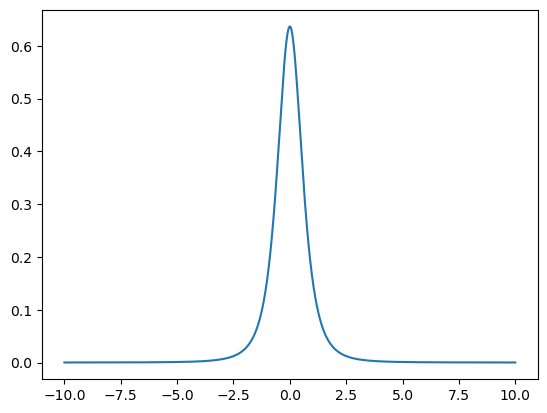

In [227]:
test_model = "scenario_1___nu=3"
test_rep   = 0
date = "2025-07-08"
sim_database[test_model]["replications"][test_rep]["densities"].loc[:, date].plot(label="kde")
database[0]["df_densities"].loc[:,date].plot(label="actual")
plt.legend()

In [4]:
os.listdir(CV_FILES_PATH)

[]

In [22]:
# kdes_paths = [''.join([CV_FILES_PATH, x]) for x in os.listdir(CV_FILES_PATH) if "scenario" in x]
kde_jbls_path = CV_FILES_PATH
kdes_paths = [''.join([kde_jbls_path, x]) for x in os.listdir(kde_jbls_path)]

kde_addresses = []
for path_name in kdes_paths:
    obj = joblib.load(path_name)
    kde_address = {
        "scenario":   obj["scenario"],
        "n_rep":      obj["n_rep"],
        "model_name": obj["model_name"],
        "address":    path_name
    }
    kde_addresses.append(kde_address)

kde_addresses = sorted(
    kde_addresses,
    key=lambda x: (x["scenario"], x["n_rep"], x["model_name"])
)

kde_index = {
    (d["scenario"], d["n_rep"], d["model_name"]): d["address"]
    for d in kde_addresses
}

# $Y_t=\Lambda(\hat{f_t})$

In [34]:
n_kde_addresses = len(kde_addresses)
pbar = tqdm(total=n_kde_addresses, desc="Total LQD(fhat) Progress")

for kde in kde_addresses:
    scenario_kde_dict = joblib.load(kde["address"])
    id_scenario_kde     = scenario_kde_dict["scenario"]
    n_rep               = scenario_kde_dict["n_rep"]
    model_name_path     = scenario_kde_dict['model_name']
    model_name          = scenario_kde_dict['model_name'].replace("_", " ")
    # carregar KDE
    # transformar para L2
    # salvar

    mlqdt = lqdt.mLQDT()
    model_lqd = mlqdt.transform(
        densities=scenario_kde_dict["df_densities"],
        densities_supports=scenario_kde_dict["df_support"], 
        verbose=False
        )
    # self.model_lqd.densities_to_lqdensities(verbose=False)
    
    # 2. L2 Expansion (K_dFPC)
    Y_t  = model_lqd.lqd.copy()
    Y_t.index = model_lqd.lqd_support
    
    # KdFPC_kwargs.update({
    #     "u": lqd_support,
    #     "du": model_lqd.du
    # })
    
    # model_kdfpc = dfpc.K_dFPC(lqd_values)
    # model_kdfpc.fit(**KdFPC_kwargs)

    # Y_t = pd.DataFrame(model_kdfpc.Y)
    # Y_t.columns = df_densities.columns
    # Y_t.index   = model_lqd.lqd_support

    kde_mlqdt_result = {
                "scenario":     kde["scenario"],
                "n_rep":        kde["n_rep"],
                "model_name":   kde["model_name"],
                "kde_mlqdt":    Y_t
        }
    
    joblib.dump(kde_mlqdt_result, f"{KDE_LQD_PATH}lqd___scenario_{id_scenario_kde}___rep_{n_rep}___kde_{model_name_path}.jbl")

    pbar.update(1)

Total LQD(fhat) Progress:   0%|          | 0/1800 [00:00<?, ?it/s]

/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: overflow encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:504: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


In [62]:
# kdes_lqd_paths = [''.join([KDE_LQD_PATH, x]) for x in os.listdir(KDE_LQD_PATH) if "scenario" in x]
kdes_lqd_paths = [''.join([KDE_LQD_PATH, x]) for x in os.listdir(KDE_LQD_PATH)]


kdes_lqd_addresses = []
for path_name in kdes_lqd_paths:
    obj = joblib.load(path_name)
    kde_address = {
        "scenario":   obj["scenario"],
        "n_rep":      obj["n_rep"],
        "model_name": obj["model_name"],
        "address":    path_name
    }
    kdes_lqd_addresses.append(kde_address)

kde_lqd_index = {
    (d["scenario"], d["n_rep"], d["model_name"]): d["address"]
    for d in kdes_lqd_addresses
}

# Cross-validation

In [41]:
# 1. Setup Logger
logger = logging.getLogger("Density_Estimation")
logger.setLevel(logging.DEBUG)

# 2. Setup File Handler
file_handler = logging.FileHandler(LOG_PATH)
file_handler.setFormatter(logging.Formatter('%(asctime)s | %(levelname)s | %(message)s'))
logger.addHandler(file_handler)

# 3. CAPTURE WARNINGS: This handles "Forecast with mean" style warnings
logging.captureWarnings(True)

In [48]:
KdFPC_kwargs = {
    "p": 5,
    # "select_ncomp": "variance",
    "dimension": 3
}

In [49]:
initial_window = 200
horizon=1

total_models = len(kde_addresses)
pbar = tqdm(total=total_models, desc="Total CV Progress")

logger.info("\nInitiating cross validation...")
for kde_address in kde_addresses:
    print(kde_address)
    scenario_kde_dict = joblib.load(kde_address["address"])

    # KDE database
    id_scenario_kde     = scenario_kde_dict["scenario"]
    sim_info            = simulations_database[id_scenario_kde]["params"]
    n_rep               = scenario_kde_dict["n_rep"]
    model_name_path     = scenario_kde_dict['model_name']
    model_name          = scenario_kde_dict['model_name'].replace("_", " ")
    logger.info(
            f"Scenario: {id_scenario_kde} | n_rep: {n_rep} | KDE model: {model_name}"
            )

    df_support, df_densities = scenario_kde_dict["df_support"], scenario_kde_dict["df_densities"]

    # Simulations database
    sim_densities         = simulations_database[id_scenario_kde]["replications"][n_rep]["densities"]
    sim_densities_supp    = sim_densities.copy()
    sim_densities_supp.loc[:,:] = sim_densities_supp.index.to_numpy()[:, None]


    # L2 database
    kde_lqd_address       = kde_lqd_index.get((id_scenario_kde, n_rep, scenario_kde_dict['model_name']))
    scenario_kde_lqd      = joblib.load(kde_lqd_address)["kde_mlqdt"]
    scenario_kde_lqd_supp = scenario_kde_lqd.copy()
    scenario_kde_lqd_supp.loc[:,:] = scenario_kde_lqd_supp.index.to_numpy()[:, None]
    
    # Cross-validation
    windows = crossVal.expanding_window_cv(df_densities.shape[1], h=horizon, initial_window=initial_window)
#     curves_hist = []
    measures = []
    for fold, window in enumerate(windows):
            fold += 1
            print(f"\t\t>>> cv {fold}/{len(windows)}")
            idx_train      = window[0]
            idx_test       = window[1]
            test_date      = df_densities.columns[idx_test]
            
            #------------ target variables ------------#
            Y_t_support, Y_t                   = scenario_kde_lqd_supp.loc[:, test_date], scenario_kde_lqd.loc[:, test_date]
            # lambda(f_{n+1})
            # X_boot
            f_hat_t_supp, f_hat_t = df_support.loc[:, test_date], df_densities.loc[:, test_date]
            f_t_support,  f_t     = sim_densities_supp.loc[:, test_date], sim_densities.loc[:, test_date]
            # lambda^{-1}(X_boot)
            #-----------------------------------------#

            # Train-test split
            kde_train_support, kde_train = df_support.iloc[:,idx_train], df_densities.iloc[:,idx_train]
            
            # Forecasting
            forecaster = fp.DensityForecaster(kdfpc_kwargs=KdFPC_kwargs, maxlags=10)
            forecaster.fit(kde_train, kde_train_support)
            mdfpc_fc = forecaster.predict(horizon=1, var_lags=None, forecast_index=test_date)

            # Predictions
            Y_hat_t = mdfpc_fc["future_L2_curves"]

            lambda_inv_Y_hat_t_supp=  mdfpc_fc["future_supports"]
            lambda_inv_Y_hat_t =      mdfpc_fc["future_densities"]

            #------------ common grid ------------#
            # \hat{Y}_{n+1} x  Y_{n+1}
            acc_measures = acc.overall_measures(forecast=Y_hat_t, test=Y_t)
            temp_df = pd.DataFrame({
                    "support":  Y_t.index,
                    "actual":   Y_t.iloc[:, 0].values,
                    "forecast": Y_hat_t.iloc[:, 0].values,
                    "date":     test_date[0],
                    "fold":     fold
                    }).set_index(["fold", "date", "support"])
            measures.append({
                    "scenario":   id_scenario_kde,
                    "n_rep":      n_rep,
                    "model_name": model_name,
                    "fold":       fold,
                    "comparison": "yHatFc_Y",
                    "fc_date":    test_date[0],
                    **acc_measures,
                    "curves":     temp_df
            })
            # \Lambda^{-1}(\hat{Y}_{n+1}) x  \hat{f}_{n+1}
            df_supp, df_kde, df_fc = fdaUtils.align_densities(
                                            f_hat_t_supp, 
                                            f_hat_t, 
                                            lambda_inv_Y_hat_t_supp, 
                                            lambda_inv_Y_hat_t, 
                                            lambda_inv_Y_hat_t.columns
                                            )
            acc_measures = acc.overall_measures(forecast=df_fc, test=df_kde)
            temp_df = pd.DataFrame({
                    "support":  df_support.iloc[:,0].values,
                    "actual":   df_kde.iloc[:, 0].values,
                    "forecast": df_fc.iloc[:, 0].values,
                    "date":     test_date[0],
                    "fold":     fold
                    }).set_index(["fold", "date", "support"])
            measures.append({
                    "scenario":   id_scenario_kde,
                    "n_rep":      n_rep,
                    "model_name": model_name,
                    "fold":       fold,
                    "comparison": "fHatFc_fHat",
                    "fc_date":    test_date[0],
                    **acc_measures,
                    "curves":     temp_df
            })
            # \Lambda^{-1}(\hat{Y}_{n+1}) x  f_{n+1}
            df_supp, df_kde, df_fc = fdaUtils.align_densities(
                                            f_t_support, 
                                            f_t, 
                                            lambda_inv_Y_hat_t_supp, 
                                            lambda_inv_Y_hat_t, 
                                            lambda_inv_Y_hat_t.columns
                                            )
            acc_measures = acc.overall_measures(forecast=df_fc, test=df_kde)
            temp_df = pd.DataFrame({
                    "support":  df_support.iloc[:,0].values,
                    "actual":   df_kde.iloc[:, 0].values,
                    "forecast": df_fc.iloc[:, 0].values,
                    "date":     test_date[0],
                    "fold":     fold
                    }).set_index(["fold", "date", "support"])
            measures.append({
                    "scenario":   id_scenario_kde,
                    "n_rep":      n_rep,
                    "model_name": model_name,
                    "fold": fold,
                    "comparison": "fHatTp1Fc_f",
                    "fc_date":    test_date[0],
                    **acc_measures,
                    "curves":     temp_df
            })
    joblib.dump(measures, f"{CV_FC_PATH}cvFc___scenario_{id_scenario_kde}___rep_{n_rep}___kde_{model_name_path}.jbl")
    pbar.update(1)

Total CV Progress:   0%|          | 0/1800 [00:00<?, ?it/s]

{'scenario': 'scenario_1___nu=3', 'n_rep': 0, 'model_name': 'gaussian_adaptive', 'address': '../data/interim/simulation/20260503/progress/scenario_1___nu=3___rep_0___kde_gaussian_adaptive.jbl'}
		>>> cv 1/100
		>>> cv 2/100
		>>> cv 3/100
		>>> cv 4/100
		>>> cv 5/100
		>>> cv 6/100
		>>> cv 7/100
		>>> cv 8/100
		>>> cv 9/100
		>>> cv 10/100
		>>> cv 11/100
		>>> cv 12/100
		>>> cv 13/100
		>>> cv 14/100
		>>> cv 15/100
		>>> cv 16/100
		>>> cv 17/100
		>>> cv 18/100
		>>> cv 19/100
		>>> cv 20/100
		>>> cv 21/100
		>>> cv 22/100
		>>> cv 23/100
		>>> cv 24/100
		>>> cv 25/100
		>>> cv 26/100
		>>> cv 27/100
		>>> cv 28/100
		>>> cv 29/100
		>>> cv 30/100
		>>> cv 31/100
		>>> cv 32/100
		>>> cv 33/100
		>>> cv 34/100
		>>> cv 35/100
		>>> cv 36/100
		>>> cv 37/100
		>>> cv 38/100
		>>> cv 39/100
		>>> cv 40/100
		>>> cv 41/100
		>>> cv 42/100
		>>> cv 43/100
		>>> cv 44/100
		>>> cv 45/100
		>>> cv 46/100
		>>> cv 47/100
		>>> cv 48/100
		>>> cv 49/100
		>>> cv 50/100
		>>> cv 51/100

LinAlgError: Array must not contain infs or NaNs

In [52]:
import multiprocessing

In [51]:
import multiprocessing
import time
import math

# A CPU-heavy task to simulate real work
def heavy_computation(n):
    # Finding the square root of a large number many times
    result = 0
    for i in range(n):
        result += math.sqrt(i)
    return result

def main():
    # 1. Determine the number of available cores
    # On an M5 Pro, this will reflect the P-cores and E-cores combined.
    num_cores = multiprocessing.cpu_count()
    print(f"Detected {num_cores} cores on this M5 Pro.")

    # 2. Create a list of tasks
    tasks = [10**7] * 20  # 20 independent tasks
    
    print(f"Starting parallel processing of {len(tasks)} tasks...")
    start_time = time.time()

    # 3. Initialize the Pool
    # Using 'with' ensures the processes are cleaned up automatically
    with multiprocessing.Pool(processes=num_cores) as pool:
        # map() distributes the tasks across the available cores
        results = pool.map(heavy_computation, tasks)

    end_time = time.time()
    
    print(f"Finished in {end_time - start_time:.2f} seconds.")
    print(f"Processed {len(results)} results.")


main()

Detected 10 cores on this M5 Pro.
Starting parallel processing of 20 tasks...


Process SpawnPoolWorker-31:
Process SpawnPoolWorker-32:
Process SpawnPoolWorker-33:
Process SpawnPoolWorker-34:
Process SpawnPoolWorker-35:
Process SpawnPoolWorker-36:
Process SpawnPoolWorker-37:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/opt/anaconda3/envs/densities4risk/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/anaconda3/envs/densities4risk/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/anaconda3/envs/densities4risk/lib/python3.11/multiprocessing/pool.py", line 114, in worker
    task = get()
           ^^^^^
  File "/opt/anaconda3/envs/densities4risk/lib/python3.11/multiprocessing/queues.py", line 367, in get
    return _ForkingPickler.loads(res)
    

KeyboardInterrupt: 

In [53]:
import multiprocessing as mp

def worker(task):
    """
    Example worker function.
    Replace this with your actual computation.
    """
    x, y = task
    return x * y  # placeholder computation


def run_parallel(tasks, n_cores=None):
    """
    Run tasks in parallel using multiprocessing.
    
    Parameters
    ----------
    tasks : list
        List of inputs for the worker function
    n_cores : int or None
        Number of cores to use. If None, uses all available cores.
    """
    if n_cores is None:
        n_cores = mp.cpu_count()

    # Important for macOS + Jupyter
    ctx = mp.get_context("spawn")

    with ctx.Pool(processes=n_cores) as pool:
        results = pool.map(worker, tasks)

    return results

In [56]:
from concurrent.futures import ProcessPoolExecutor
import multiprocessing as mp

def worker(x):
    return x * x

def run_parallel(data, n_cores=None):
    if n_cores is None:
        n_cores = mp.cpu_count()

    with ProcessPoolExecutor(max_workers=n_cores) as executor:
        results = list(executor.map(worker, data))

    return results

In [57]:
tasks = [(i, i+1) for i in range(1000)]

results = run_parallel(tasks)

print(results[:10])

Process SpawnProcess-111:
Process SpawnProcess-112:
Traceback (most recent call last):
Traceback (most recent call last):
  File "/opt/anaconda3/envs/densities4risk/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/anaconda3/envs/densities4risk/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/anaconda3/envs/densities4risk/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/anaconda3/envs/densities4risk/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/anaconda3/envs/densities4risk/lib/python3.11/concurrent/futures/process.py", line 249, in _process_worker
    call_item = call_queue.get(block=True)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/densities4risk/lib/python3.11/concurrent/futures/process.py", line 249, in _process_worker
  

BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.